This project uses 200 Chest X-ray images selected from the publicly available Kaggle Chest X-ray dataset.Only normal X-ray images were used for training an autoencoder to learn image reconstruction.

## Installing Required Libraries

This step installs all necessary Python libraries required for training and visualization.


In [1]:
import os
import cv2
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt
import seaborn as sns


## Dataset Loading and Preprocessing

Chest X-ray images are loaded, resized, normalized, and converted into PyTorch tensors.


In [2]:
class XRayDataset(Dataset):
    def __init__(self, image_dir, img_size=64):
        self.image_dir = image_dir
        self.img_size = img_size
        self.images = os.listdir(image_dir)

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img_path = os.path.join(self.image_dir, self.images[idx])
        img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        img = cv2.resize(img, (self.img_size, self.img_size))
        img = img / 255.0
        img = torch.tensor(img, dtype=torch.float32).unsqueeze(0)
        return img


## Train–Validation Split

The dataset is split into training and validation sets to evaluate model performance.


In [3]:
dataset = XRayDataset("data/images")

train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=16, shuffle=False)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))


Train samples: 160
Validation samples: 40


## Autoencoder Model Architecture

A convolutional autoencoder is defined with encoder and decoder components
for learning compact image representations.


In [4]:
class AutoEncoder(nn.Module):
    def __init__(self):
        super().__init__()

        self.encoder = nn.Sequential(
            nn.Conv2d(1, 16, 3, stride=2, padding=1),
            nn.ReLU(),
            nn.Conv2d(16, 32, 3, stride=2, padding=1),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(32, 16, 3, stride=2, padding=1, output_padding=1),
            nn.ReLU(),
            nn.ConvTranspose2d(16, 1, 3, stride=2, padding=1, output_padding=1),
            nn.Sigmoid()
        )

    def forward(self, x):
        encoded = self.encoder(x)
        decoded = self.decoder(encoded)
        return encoded, decoded


## Model Training

The autoencoder is trained using Mean Squared Error loss and Adam optimizer.
Validation loss is monitored to avoid overfitting.


In [5]:
model = AutoEncoder()
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)


In [6]:
epochs = 10
for epoch in range(epochs):
    model.train()
    train_loss = 0
    for data in train_loader:
        _, output = model(data)
        loss = criterion(output, data)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for data in val_loader:
            _, output = model(data)
            loss = criterion(output, data)
            val_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} | Train Loss: {train_loss:.4f} | Val Loss: {val_loss:.4f}")


Epoch 1/10 | Train Loss: 0.6482 | Val Loss: 0.1959
Epoch 2/10 | Train Loss: 0.6112 | Val Loss: 0.1800
Epoch 3/10 | Train Loss: 0.5385 | Val Loss: 0.1478
Epoch 4/10 | Train Loss: 0.4118 | Val Loss: 0.1034
Epoch 5/10 | Train Loss: 0.2803 | Val Loss: 0.0716
Epoch 6/10 | Train Loss: 0.2022 | Val Loss: 0.0539
Epoch 7/10 | Train Loss: 0.1588 | Val Loss: 0.0445
Epoch 8/10 | Train Loss: 0.1340 | Val Loss: 0.0379
Epoch 9/10 | Train Loss: 0.1147 | Val Loss: 0.0329
Epoch 10/10 | Train Loss: 0.1001 | Val Loss: 0.0289


## Image Reconstruction Results

Original and reconstructed chest X-ray images are visualized to evaluate reconstruction quality.


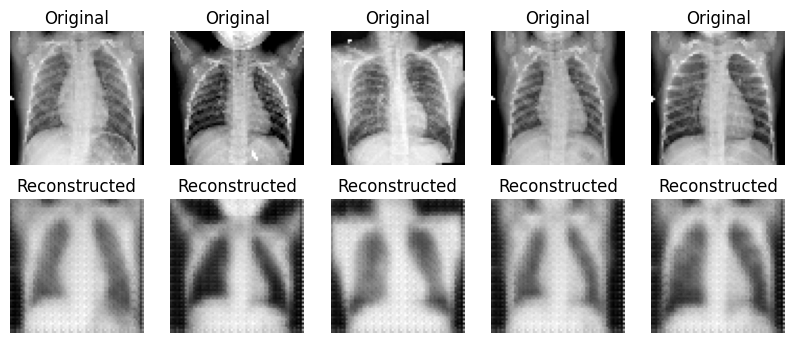

In [7]:
data_iter = iter(val_loader)
images = next(data_iter)
encoded, reconstructed = model(images)
plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(2,5,i+1)
    plt.imshow(images[i][0], cmap='gray')
    plt.title("Original")
    plt.axis('off')
    plt.subplot(2,5,i+6)
    plt.imshow(reconstructed[i][0].detach(), cmap='gray')
    plt.title("Reconstructed")
    plt.axis('off')
plt.show()

## Reconstruction Error Heatmap

A heatmap is generated to visualize pixel-wise reconstruction error in the X-ray images.


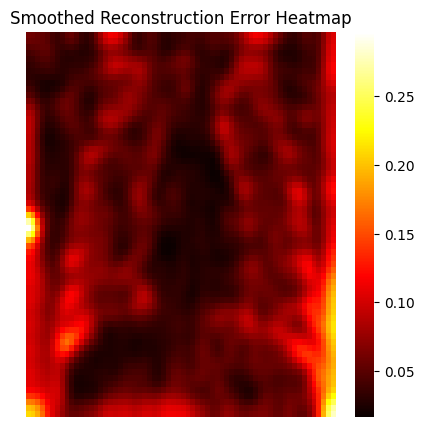

In [9]:
error = torch.abs(images[0] - reconstructed[0])
error = error.squeeze().detach().numpy()
import cv2
error_smooth = cv2.GaussianBlur(error, (7, 7), 0)
plt.figure(figsize=(5,5))
sns.heatmap(error_smooth, cmap="hot")
plt.title("Smoothed Reconstruction Error Heatmap")
plt.axis('off')
plt.show()



## Conclusion

The autoencoder successfully learns compressed representations of chest X-ray images.
Reconstruction error analysis provides insights into challenging anatomical regions.

